## Learning goals

By the end of this lesson, you should be able to:

- explain why some datasets cannot be separated by a hyperplane in the original feature space;
- define a feature map $\phi$ and describe what it does geometrically;
- state the kernel trick and explain how it avoids computing $\phi(\mathbf{x})$ explicitly;
- identify the RBF and polynomial kernels and describe their parameters; and
- write the kernel SVM decision function in terms of support vectors and the kernel.

::: {.callout-note}
This lesson assumes familiarity with the SVM margin and dual formulation covered in the [Support Vector Machines](1.0-svm.ipynb) notebook.
:::

## 1. When a linear classifier fails

A hyperplane in $\mathbb{R}^d$ can correctly separate two classes only when they are **linearly separable**. Consider a binary dataset

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N},
\qquad \mathbf{x}_i\in\mathbb{R}^d,\quad y_i\in\{-1,+1\}.
$$

For a concentric-ring layout, the signed decision function $f(\mathbf{x})=\operatorname{sign}(\mathbf{w}^\top\mathbf{x}+b)$ will misclassify some observations for every choice of $\mathbf{w}$ and $b$.

In [1]:
#| label: setup
#| include: false

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel
from sklearn.svm import SVC

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

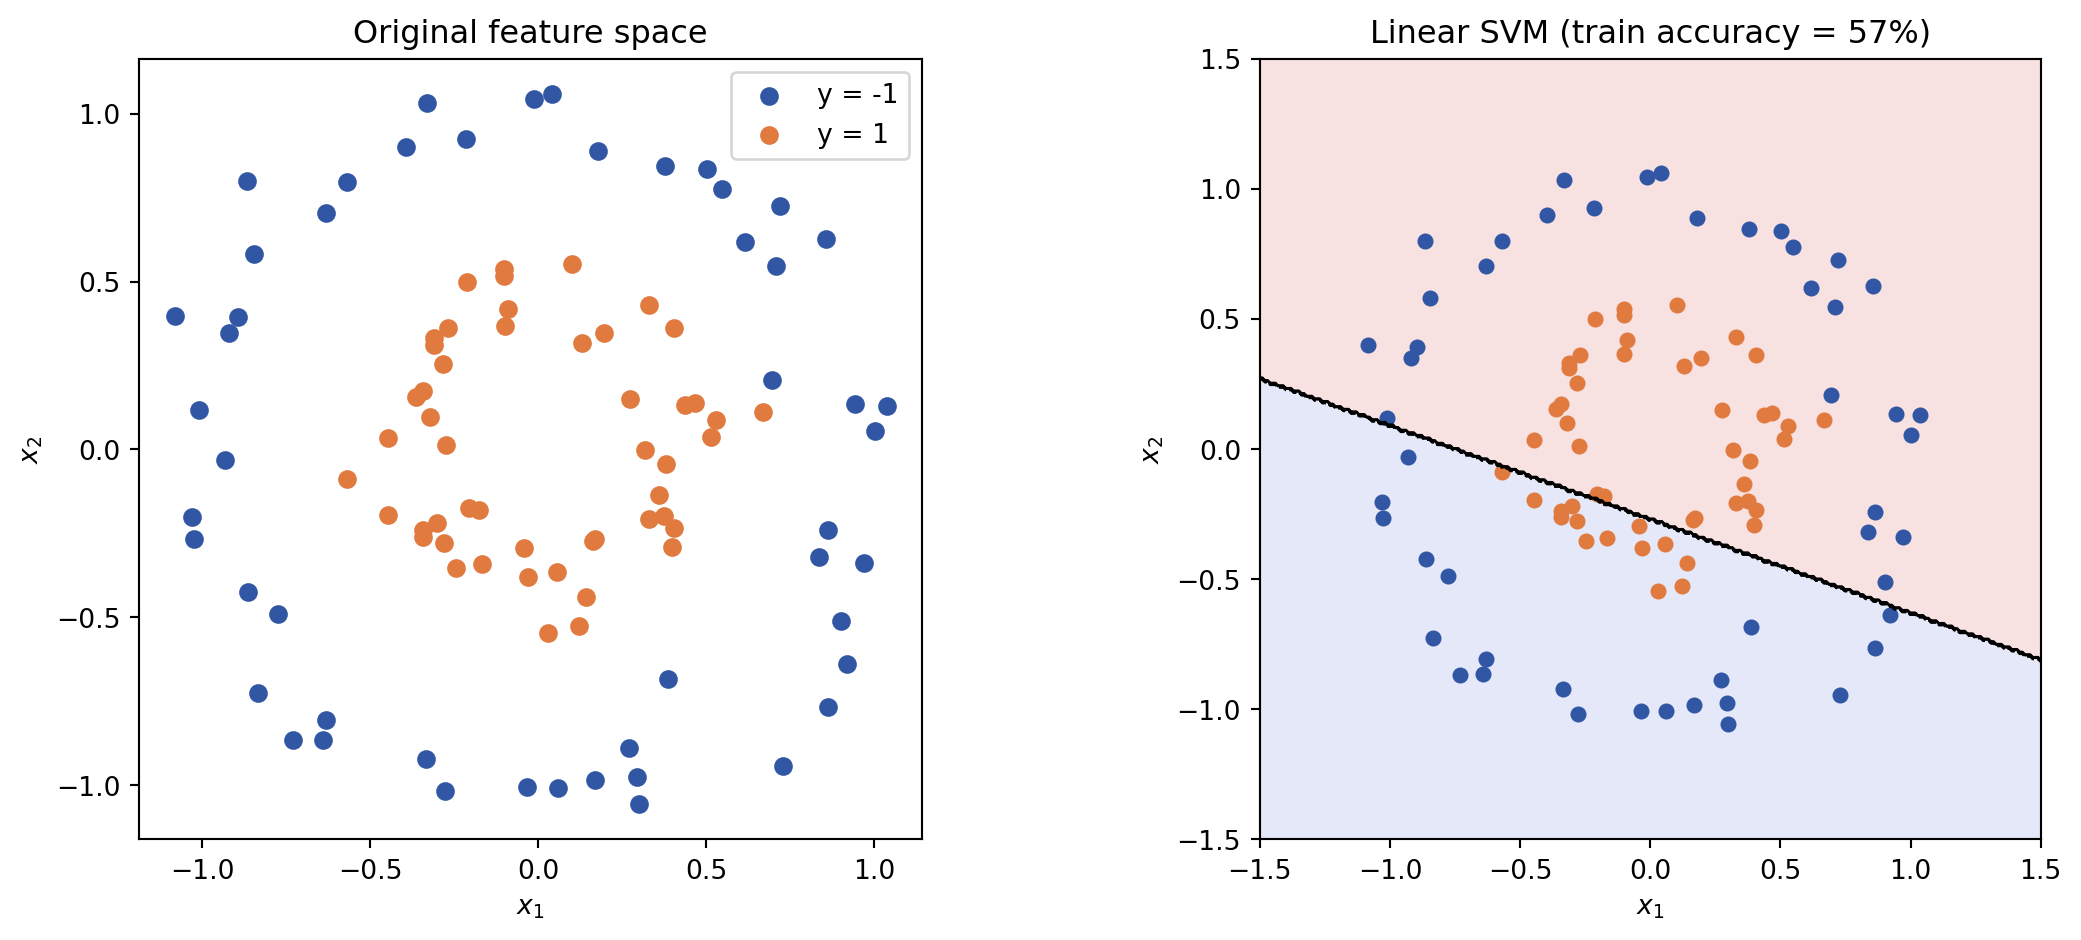

In [2]:
#| label: fig-circles
#| fig-cap: "Concentric rings: no hyperplane separates the two classes."

X, y = make_circles(n_samples=100, noise=0.10, factor=0.4, random_state=RANDOM_SEED)
y = 2 * y - 1  # map {0, 1} to {-1, +1}

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
clf_lin = SVC(kernel='linear', C=1.0)
clf_lin.fit(X, y)
Z_lin = clf_lin.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
    ax.scatter(*X[y == lbl].T, c=color, label=f'y = {lbl}')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Original feature space', aspect='equal')
ax.legend()

ax2 = axes[1]
ax2.contourf(xx, yy, Z_lin, alpha=0.15, cmap='coolwarm')
ax2.contour(xx, yy, Z_lin, colors='k', linewidths=0.8)
for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
    ax2.scatter(*X[y == lbl].T, c=color, s=25)
acc_lin = (clf_lin.predict(X) == y).mean()
ax2.set(xlabel='$x_1$', ylabel='$x_2$',
        title=f'Linear SVM (train accuracy = {acc_lin:.0%})', aspect='equal')

plt.tight_layout()
plt.show()

## 2. Feature maps

A **feature map** $\phi$ lifts each observation from $\mathbb{R}^d$ into a (possibly higher-dimensional) Hilbert space $\mathcal{H}$:

$$
\phi:\mathbb{R}^d\to\mathcal{H}.
$$

Choosing $\phi$ so that the lifted observations are linearly separable allows the standard linear SVM to operate in $\mathcal{H}$.

**Example.** For $d=2$, define the degree-2 polynomial feature map

$$
\phi(x_1,x_2)
=\bigl(x_1^2,\;\sqrt{2}\,x_1 x_2,\;x_2^2\bigr)\in\mathbb{R}^3.
$$

After this lift, the two concentric rings become linearly separable by a **plane** in $\mathbb{R}^3$.

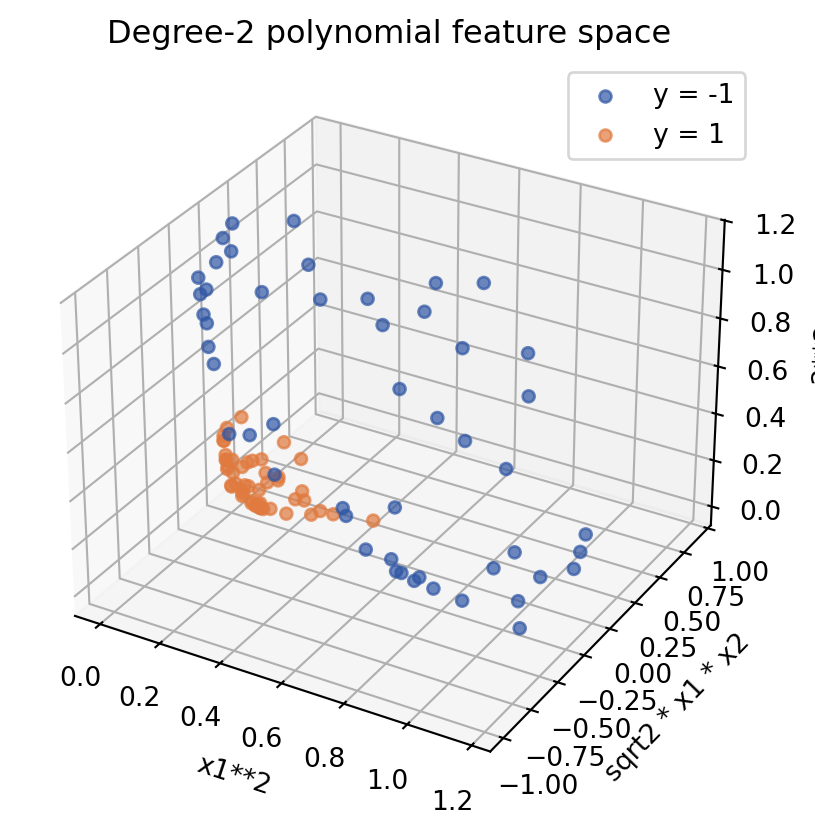

In [3]:
#| label: fig-feature-map
#| fig-cap: "After the polynomial feature map, the two rings are linearly separable."

def phi_poly2(Xin):
    u, v = Xin[:, 0], Xin[:, 1]
    return np.column_stack([u**2, np.sqrt(2) * u * v, v**2])

X_lifted = phi_poly2(X)

fig = plt.figure(figsize=(7, 5))
ax3d = fig.add_subplot(111, projection='3d')
for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
    ax3d.scatter(*X_lifted[y == lbl].T, c=color, label=f'y = {lbl}', alpha=0.7)
ax3d.set_xlabel('x1**2')
ax3d.set_ylabel('sqrt2 * x1 * x2')
ax3d.set_zlabel('x2**2')
ax3d.set_title('Degree-2 polynomial feature space')
ax3d.legend()
plt.show()

## 3. The kernel trick

Constructing $\phi(\mathbf{x})$ explicitly can be expensive or impossible when $\mathcal{H}$ is infinite-dimensional. The **kernel trick** observes that the SVM dual depends on $\phi$ only through **inner products** $\langle\phi(\mathbf{x}),\phi(\mathbf{z})\rangle_{\mathcal{H}}$.

A **kernel function** computes this inner product directly, without ever forming $\phi$:

$$
k(\mathbf{x},\mathbf{z})
=\langle\phi(\mathbf{x}),\phi(\mathbf{z})\rangle_{\mathcal{H}}.
$$

Two widely used kernels are:

| Kernel | Formula | Parameter |
|--------|---------|-----------|
| Polynomial | $k_\mathrm{poly}(\mathbf{x},\mathbf{z})=(1+\mathbf{x}^\top\mathbf{z})^p$ | degree $p$ |
| RBF (Gaussian) | $k_\mathrm{RBF}(\mathbf{x},\mathbf{z})=\exp\!\left(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2\right)$ | bandwidth $\gamma$ |

The RBF kernel corresponds to an **infinite-dimensional** feature space; $k_\mathrm{RBF}$ is a simple closed-form expression that sidesteps the need to construct that space.

The matrix $K\in\mathbb{R}^{N\times N}$ with entries $K_{ij}=k(\mathbf{x}_i,\mathbf{x}_j)$ is the **kernel matrix** (also called the Gram matrix). It encodes all pairwise similarities needed by the SVM optimiser.

/Users/skababji/Projects/EulerLettersAI/math-to-code/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skababji/Projects/EulerLettersAI/math-to-code/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skababji/Projects/EulerLettersAI/math-to-code/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


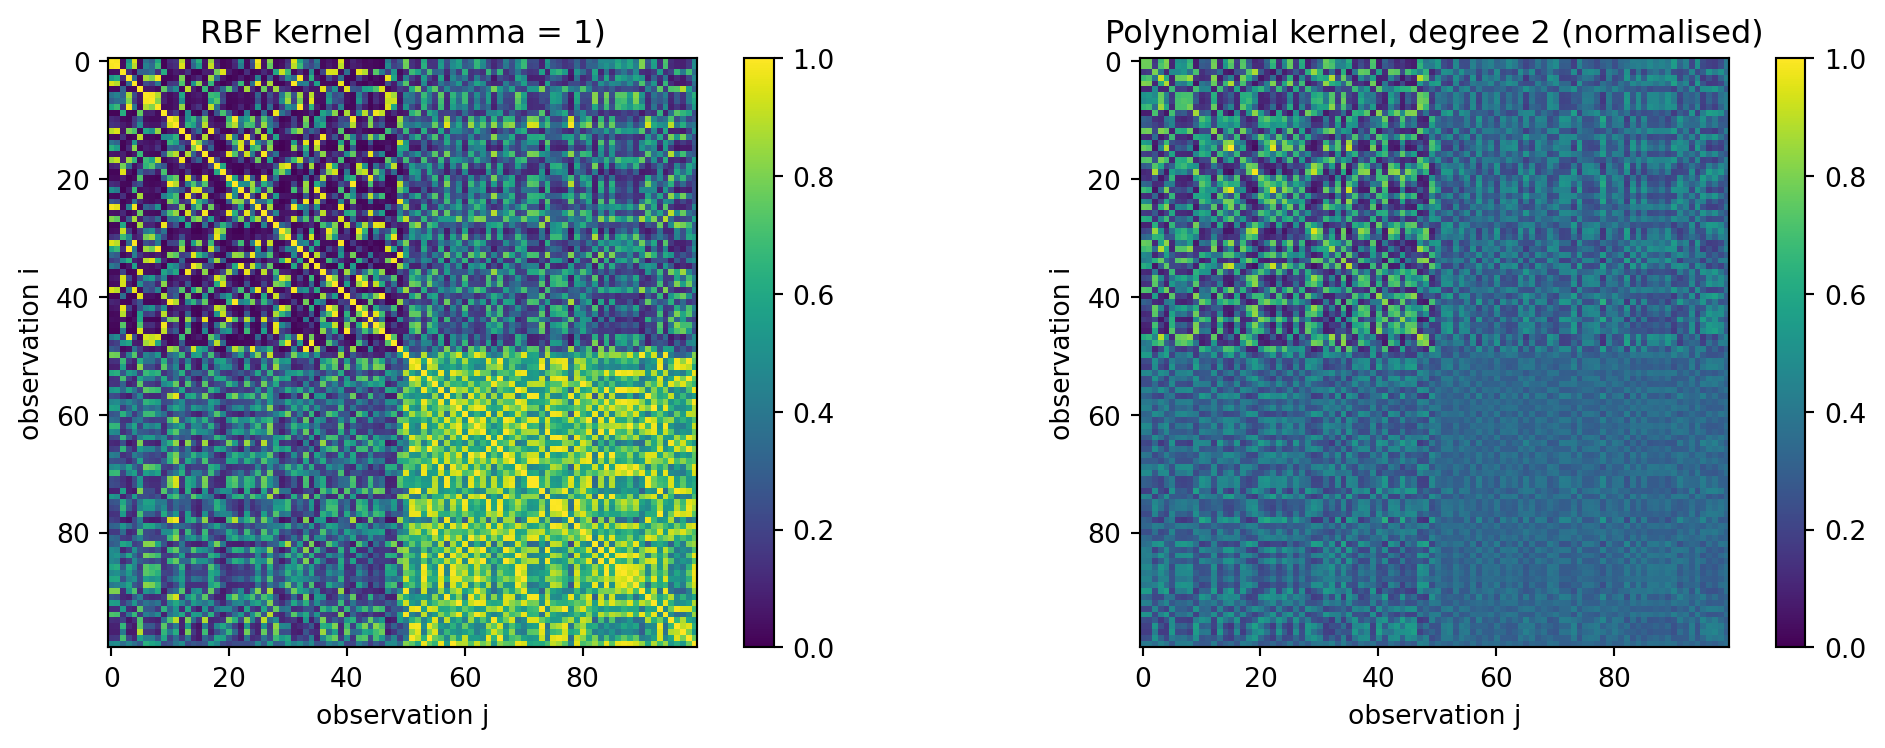

In [4]:
#| label: fig-kernel-matrix
#| fig-cap: "Kernel matrices for observations sorted by label."

idx = np.argsort(y)
X_sorted = X[idx]

K_rbf  = rbf_kernel(X_sorted, gamma=1.0)
K_poly = polynomial_kernel(X_sorted, degree=2, coef0=1)
K_poly = K_poly / K_poly.max()  # normalise for display

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, K, title in zip(
    axes,
    [K_rbf, K_poly],
    ['RBF kernel  (gamma = 1)', 'Polynomial kernel, degree 2 (normalised)'],
):
    img = ax.imshow(K, cmap='viridis', vmin=0, vmax=1)
    ax.set(xlabel='observation j', ylabel='observation i', title=title)
    fig.colorbar(img, ax=ax)
plt.tight_layout()
plt.show()

## 4. The kernel SVM decision function

Replacing $\mathbf{x}_i^\top\mathbf{x}_j$ with $k(\mathbf{x}_i,\mathbf{x}_j)$ in the SVM dual gives the **kernel SVM dual**:

$$
\max_{\boldsymbol{\alpha}}\;\sum_{i=1}^{N}\alpha_i
-\frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}
\alpha_i\alpha_j y_i y_j\,k(\mathbf{x}_i,\mathbf{x}_j)
\qquad\text{subject to}\quad
\alpha_i\geq 0,\quad\sum_{i=1}^{N}\alpha_i y_i=0.
$$

The optimisation is entirely classical regardless of whether $k$ is a classical formula or a quantum circuit.

At prediction time, the **decision function** is

$$
f(\mathbf{x})
=\operatorname{sign}\!\left(\sum_{i\in\mathcal{S}}\alpha_i y_i\,k(\mathbf{x}_i,\mathbf{x})+b\right),
$$

where $\mathcal{S}=\{i:\alpha_i>0\}$ is the support-vector index set. **Only support vectors contribute** to classifying a new observation.

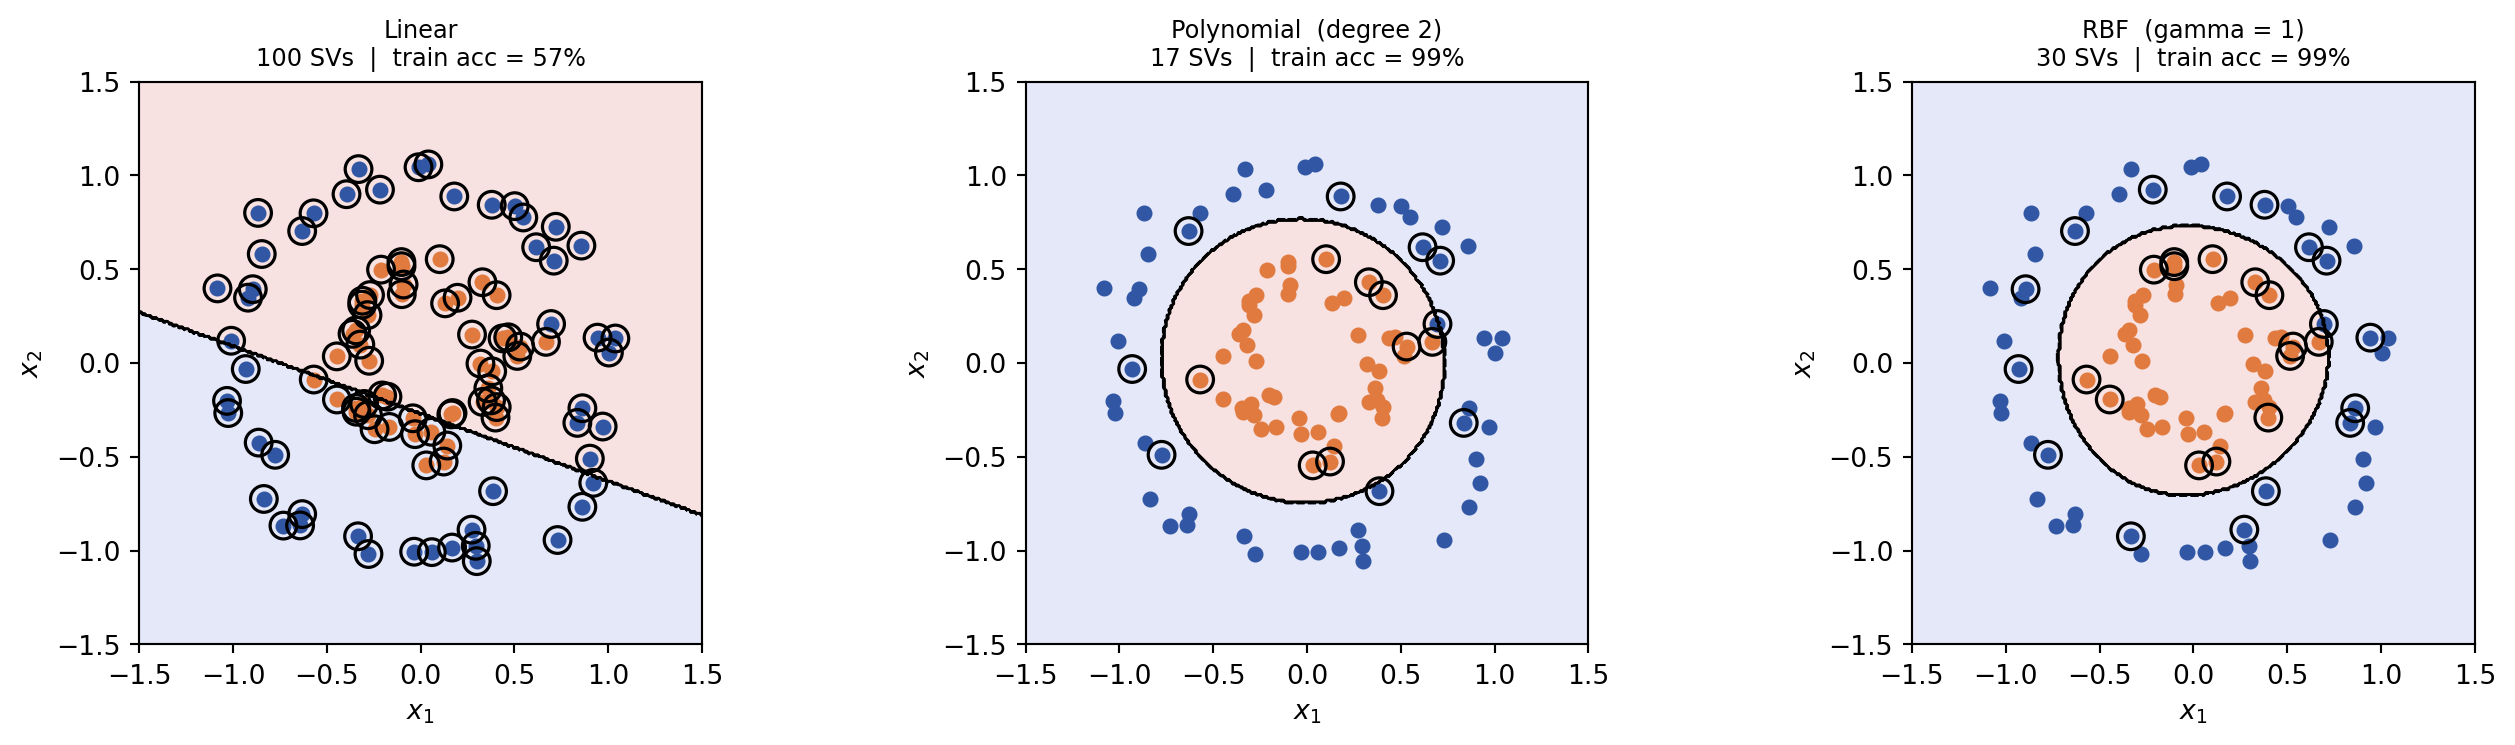

In [5]:
#| label: fig-boundaries
#| fig-cap: "Decision boundaries produced by three different kernels on the concentric-ring dataset."

configs = [
    ('linear', {},                        'Linear'),
    ('poly',   {'degree': 2, 'coef0': 1}, 'Polynomial  (degree 2)'),
    ('rbf',    {'gamma': 1.0},            'RBF  (gamma = 1)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (kernel, params, title) in zip(axes, configs):
    clf = SVC(kernel=kernel, C=1.0, **params)
    clf.fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8)
    for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
        ax.scatter(*X[y == lbl].T, c=color, s=25)
    ax.scatter(
        *X[clf.support_].T,
        s=100, facecolors='none', edgecolors='k', linewidths=1.2,
    )
    acc = (clf.predict(X) == y).mean()
    ax.set_title(f'{title}\n{len(clf.support_)} SVs  |  train acc = {acc:.0%}', fontsize=9)
    ax.set(xlabel='$x_1$', ylabel='$x_2$', aspect='equal')

plt.tight_layout()
plt.show()

## Try it yourself

1. Change `RANDOM_SEED` and rerun. Does the number of support vectors for each kernel stay roughly the same?
2. Increase `noise` in `make_circles` to `0.20`. Which kernel degrades first?
3. Try `gamma = 0.1` and `gamma = 10` for the RBF kernel. How does the decision boundary change?
4. Add a `sigmoid` kernel to the comparison. What does the decision boundary look like?